In [171]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

employee_data = pd.read_csv('/content/Messy_Employee_dataset.csv')

employee_data.head()

,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work
0,EMP1000,Bob,Davis,25.0,DevOps-California,Active,4/2/2021,59767.65,bob.davis@example.com,-1651623197,Average,True
1,EMP1001,Bob,Brown,NaN,Finance-Texas,Active,7/10/2020,65304.66,bob.brown@example.com,-1898471390,Excellent,True
2,EMP1002,Alice,Jones,NaN,Admin-Nevada,Pending,12/7/2023,88145.90,alice.jones@example.com,-5596363211,Good,True
3,EMP1003,Eva,Davis,25.0,Admin-Nevada,Inactive,11/27/2021,69450.99,eva.davis@example.com,-3476490784,Good,True
4,EMP1004,Frank,Williams,25.0,Cloud Tech-Florida,Active,1/5/2022,109324.61,frank.williams@example.com,-1586734256,Poor,False


In [172]:
print(f'No of columns: {len(employee_data.columns)}')
print(employee_data.columns.tolist())

No of columns: 12
['Employee_ID', 'First_Name', 'Last_Name', 'Age', 'Department_Region', 'Status', 'Join_Date', 'Salary', 'Email', 'Phone', 'Performance_Score', 'Remote_Work']


In [173]:
employee_data.columns = employee_data.columns.str.replace('_', ' ')

In [174]:
employee_data.columns.tolist()

['Employee ID',
 'First Name',
 'Last Name',
 'Age',
 'Department Region',
 'Status',
 'Join Date',
 'Salary',
 'Email',
 'Phone',
 'Performance Score',
 'Remote Work']

In [175]:
employee_data.duplicated().sum()

np.int64(0)

In [176]:
employee_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Employee ID        1020 non-null   object 
 1   First Name         1020 non-null   object 
 2   Last Name          1020 non-null   object 
 3   Age                809 non-null    float64
 4   Department Region  1020 non-null   object 
 5   Status             1020 non-null   object 
 6   Join Date          1020 non-null   object 
 7   Salary             996 non-null    float64
 8   Email              1020 non-null   object 
 9   Phone              1020 non-null   int64  
 10  Performance Score  1020 non-null   object 
 11  Remote Work        1020 non-null   bool   
dtypes: bool(1), float64(2), int64(1), object(8)
memory usage: 88.8+ KB


In [177]:
# converting join date from object dtype to datetime

import datetime
employee_data['Join Date'] = pd.to_datetime(employee_data['Join Date'], errors='coerce')

In [178]:
print(employee_data['Join Date'])

0      2021-04-02
1      2020-07-10
2      2023-12-07
3      2021-11-27
4      2022-01-05
          ...    
1015   2023-08-19
1016   2021-11-07
1017   2023-10-04
1018   2024-12-16
1019   2021-02-22
Name: Join Date, Length: 1020, dtype: datetime64[ns]


In [179]:
employee_data['Join Date'].dtype

dtype('<M8[ns]')

In [180]:
employee_data['Department Region'] = employee_data['Department Region'].str.replace('-', ' ')

In [181]:
def extract_department(element):
  return str(element).split()[0]
employee_data['Department'] = employee_data['Department Region'].apply(extract_department)
print(employee_data['Department'])

0        DevOps
1       Finance
2         Admin
3         Admin
4         Cloud
         ...   
1015         HR
1016      Cloud
1017    Finance
1018         HR
1019     DevOps
Name: Department, Length: 1020, dtype: object


In [182]:
def extract_region(element):
  return str(element).split()[-1]
employee_data['Region'] = employee_data['Department Region'].apply(extract_region)
print(employee_data['Region'])

0       California
1            Texas
2           Nevada
3           Nevada
4          Florida
           ...    
1015    California
1016         Texas
1017          York
1018       Florida
1019      Illinois
Name: Region, Length: 1020, dtype: object


In [183]:
employee_data['Phone'] = employee_data['Phone'].astype(str).str.replace('-', '')

In [184]:
# missing values
employee_data.isnull().sum()

,0
Employee ID,0
First Name,0
Last Name,0
Age,211
Department Region,0
Status,0
Join Date,0
Salary,24
Email,0
Phone,0


In [185]:
employee_data.columns.tolist()

['Employee ID',
 'First Name',
 'Last Name',
 'Age',
 'Department Region',
 'Status',
 'Join Date',
 'Salary',
 'Email',
 'Phone',
 'Performance Score',
 'Remote Work',
 'Department',
 'Region']

In [186]:
employee_data = employee_data.drop(columns=['Department Region'])

In [187]:
employee_data['Age'] = employee_data['Age'].fillna(employee_data['Age'].median())
employee_data['Salary'] = employee_data['Salary'].fillna(employee_data['Salary'].median())

<Axes: xlabel='Performance Score', ylabel='Department'>

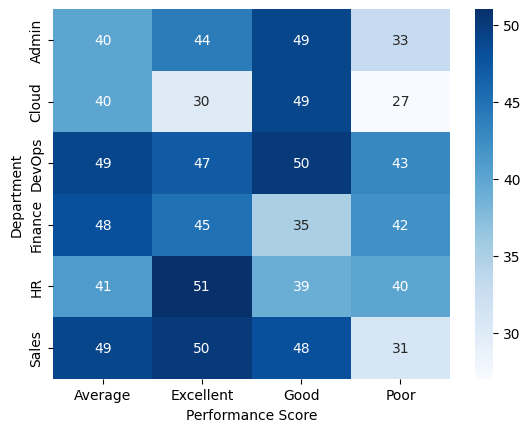

In [188]:

table = pd.pivot_table(
    employee_data,
    index='Department',
    columns='Performance Score',
    values='Employee ID',
    aggfunc='count'
)
sns.heatmap(table, annot=True, cmap='Blues')

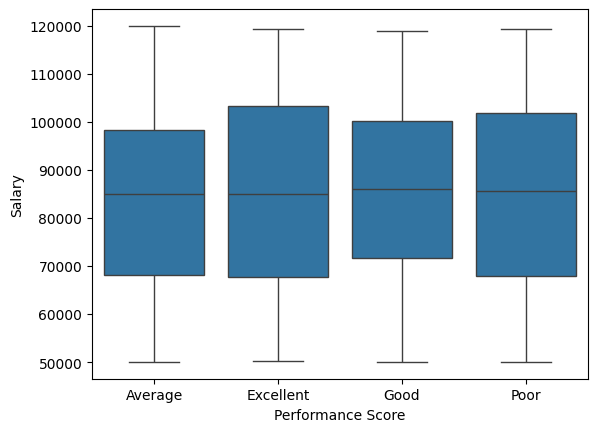

In [189]:
sns.boxplot(
    x='Performance Score',
    y='Salary',
    data=employee_data
)

plt.show()

In [190]:
employee_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Employee ID        1020 non-null   object        
 1   First Name         1020 non-null   object        
 2   Last Name          1020 non-null   object        
 3   Age                1020 non-null   float64       
 4   Status             1020 non-null   object        
 5   Join Date          1020 non-null   datetime64[ns]
 6   Salary             1020 non-null   float64       
 7   Email              1020 non-null   object        
 8   Phone              1020 non-null   object        
 9   Performance Score  1020 non-null   object        
 10  Remote Work        1020 non-null   bool          
 11  Department         1020 non-null   object        
 12  Region             1020 non-null   object        
dtypes: bool(1), datetime64[ns](1), float64(2), object(9)
memory usa

In [191]:
employee_data.head()

,Employee ID,First Name,Last Name,Age,Status,Join Date,Salary,Email,Phone,Performance Score,Remote Work,Department,Region
0,EMP1000,Bob,Davis,25.0,Active,2021-04-02,59767.65,bob.davis@example.com,1651623197,Average,True,DevOps,California
1,EMP1001,Bob,Brown,30.0,Active,2020-07-10,65304.66,bob.brown@example.com,1898471390,Excellent,True,Finance,Texas
2,EMP1002,Alice,Jones,30.0,Pending,2023-12-07,88145.90,alice.jones@example.com,5596363211,Good,True,Admin,Nevada
3,EMP1003,Eva,Davis,25.0,Inactive,2021-11-27,69450.99,eva.davis@example.com,3476490784,Good,True,Admin,Nevada
4,EMP1004,Frank,Williams,25.0,Active,2022-01-05,109324.61,frank.williams@example.com,1586734256,Poor,False,Cloud,Florida
